# EDA: LLMRouterBench Performance-Cost pool

I loaded the tidy long table that `src/load_bench.py` builds from the LLMRouterBench
bench-release files (Performance-Cost setting: 10 datasets, 13 flagship models, plus
openrouter kept aside as a reference router). One row is one (prompt, model) pair with
the tokens, dollar cost, and score that model got on that prompt.

The point of this notebook: understand the cost and quality landscape well enough to
defend a routing label rule. I am assuming the paper's own dataset/model whitelist is
the right pool because it keeps my numbers comparable to their published baselines.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_parquet(Path("..") / "data" / "processed" / "records_long.parquet")
core = df[~df.is_reference].copy()
print(df.shape)
df.head()

(173688, 11)


,dataset,split,model,is_reference,prompt_id,query_hash,query_chars,prompt_tokens,completion_tokens,cost,score
0,aime,hybrid,claude-sonnet-4,False,aime:1,ecd8ee206c14,380,232,1714,0.026406,1.0
1,aime,hybrid,claude-sonnet-4,False,aime:2,ce124f79f9bf,511,268,1630,0.025254,0.0
2,aime,hybrid,claude-sonnet-4,False,aime:3,4a1cf6eb02aa,463,201,800,0.012603,1.0
3,aime,hybrid,claude-sonnet-4,False,aime:4,d4086b92296a,425,170,1547,0.023715,1.0
4,aime,hybrid,claude-sonnet-4,False,aime:5,b053dc86254d,340,171,1541,0.023628,0.0


173,688 rows load, 13 models plus the openrouter reference. I split off `core` (the 13
routing candidates) because the reference router should never leak into label building.

In [2]:
# how many prompts each dataset contributes, and how complete the model coverage is
prompts_per_ds = core.groupby("dataset")["prompt_id"].nunique().sort_values(ascending=False)
coverage = core.groupby("prompt_id")["model"].nunique()
print(prompts_per_ds)
print(f"\nprompts with all {core.model.nunique()} models present:",
      f"{(coverage == core.model.nunique()).sum():,} of {coverage.size:,}")

dataset
simpleqa         4326
mmlupro          3000
hle              2158
livecodebench    1055
arenahard         750
swe-bench         500
tau2              278
gpqa              198
livemathbench     121
aime               60
Name: prompt_id, dtype: int64

prompts with all 13 models present: 12,168 of 12,446


The task mix is lopsided: simpleqa and mmlupro are thousands of prompts while aime is
only 60. Coverage is nearly complete, 12,168 of 12,446 prompts have all 13 models. The
label rule compares models against each other per prompt, so I planned to keep only
prompts where the full menu is present rather than compare partial menus.

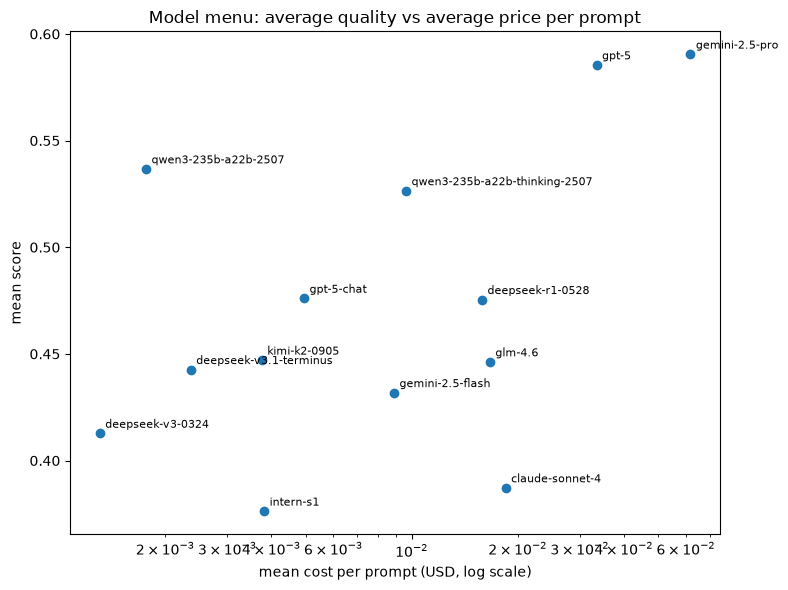

,mean_score,mean_cost
model,,
deepseek-v3-0324,0.4127,0.0013
qwen3-235b-a22b-2507,0.5367,0.0018
deepseek-v3.1-terminus,0.4426,0.0024
kimi-k2-0905,0.4471,0.0038
intern-s1,0.3763,0.0038
gpt-5-chat,0.4760,0.0049
gemini-2.5-flash,0.4318,0.0089
qwen3-235b-a22b-thinking-2507,0.5265,0.0096
deepseek-r1-0528,0.4755,0.0158


In [3]:
# the menu: what each model costs on average vs how often it answers well
menu = core.groupby("model").agg(mean_score=("score", "mean"),
                                 mean_cost=("cost", "mean")).sort_values("mean_cost")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(menu.mean_cost, menu.mean_score)
for name, row in menu.iterrows():
    ax.annotate(name, (row.mean_cost, row.mean_score), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("mean cost per prompt (USD, log scale)")
ax.set_ylabel("mean score")
ax.set_title("Model menu: average quality vs average price per prompt")
plt.tight_layout()
plt.show()
menu.round(4)

This chart is the whole reason the project exists. The price spread is about 47x
between deepseek-v3-0324 (\$0.0013 a prompt on average) and gemini-2.5-pro (\$0.0617),
but the quality spread is much narrower, roughly 0.38 to 0.59 mean score. qwen3-235b-a22b-2507
sits in a sweet spot: second-cheapest with a 0.54 mean score, above several models that
cost 5 to 10 times more. Paying more does not reliably buy more correctness, which is
exactly the gap a router can exploit.

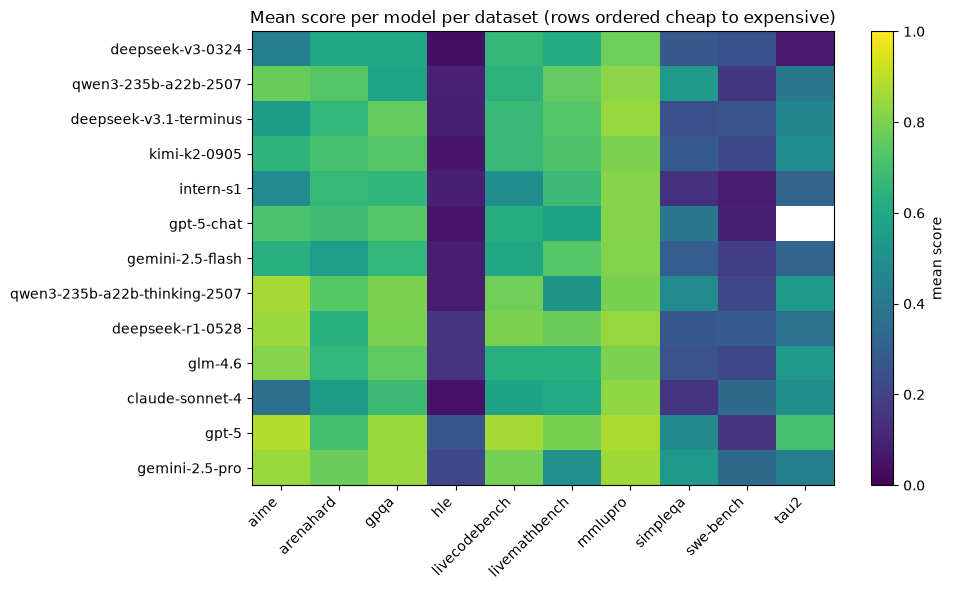

In [4]:
# where each model is strong: mean score per (model, dataset)
pivot = core.pivot_table(index="model", columns="dataset", values="score", aggfunc="mean")
pivot = pivot.loc[menu.index]  # keep cheap-to-expensive order
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_title("Mean score per model per dataset (rows ordered cheap to expensive)")
fig.colorbar(im, label="mean score")
plt.tight_layout()
plt.show()

No single row wins every column. gpt-5 and gemini-2.5-pro lead the hard reasoning sets
(aime, gpqa, livecodebench), but cheaper models hold their own on simpleqa and mmlupro,
and everything struggles on hle. The strong dataset-level structure also hints that task
category will be a useful feature for the router, models are consistently good or bad per
domain rather than per individual prompt.

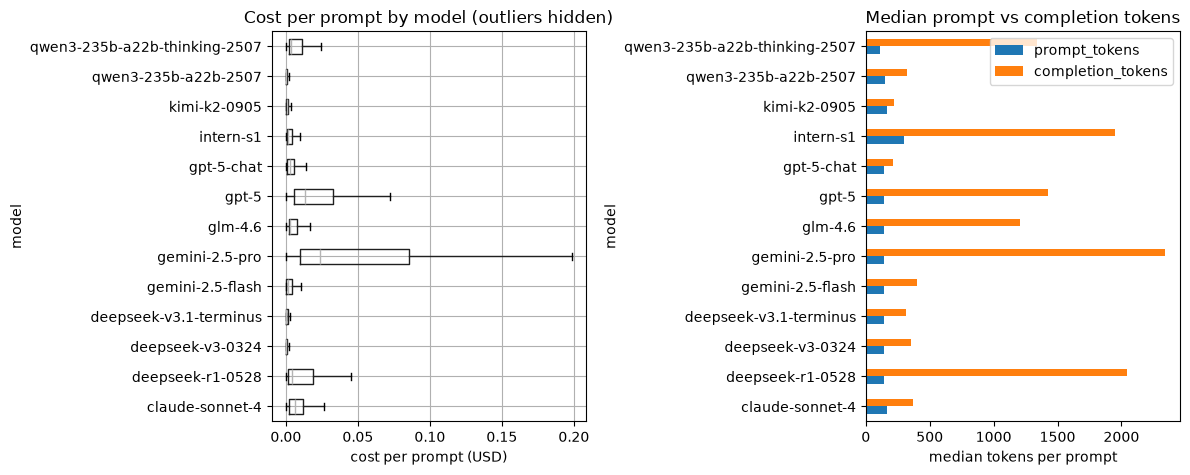

In [5]:
# what drives cost: completion tokens dwarf prompt tokens for reasoning models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
core.boxplot(column="cost", by="model", ax=axes[0], vert=False, showfliers=False)
axes[0].set_xlabel("cost per prompt (USD)")
axes[0].set_title("Cost per prompt by model (outliers hidden)")
tok = core.groupby("model")[["prompt_tokens", "completion_tokens"]].median()
tok.plot.barh(ax=axes[1])
axes[1].set_xlabel("median tokens per prompt")
axes[1].set_title("Median prompt vs completion tokens")
plt.suptitle("")
plt.tight_layout()
plt.show()

Completion tokens, not prompt tokens, drive the bill. The thinking-style models
(deepseek-r1-0528, qwen3 thinking, gemini-2.5-pro) write thousands of tokens per answer
while gpt-5-chat and kimi stay compact. That matters for the label: a prompt's cost
depends on which model reads it, so the router's features can only use what is known
before the call (prompt size, task category), never the completion side.

In [6]:
# score style per dataset: which datasets grade 0/1 and which give partial credit
for ds, g in core.groupby("dataset"):
    vals = sorted(g.score.round(3).unique())
    style = "binary" if set(vals) <= {0.0, 1.0} else f"values {vals}"
    print(f"{ds:15s} {style}")

aime            binary
arenahard       values [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
gpqa            binary
hle             binary
livecodebench   binary
livemathbench   binary
mmlupro         binary
simpleqa        binary
swe-bench       binary
tau2            binary


Nine of ten datasets grade strictly 0 or 1. Only arenahard gives partial credit (0.5
for a draw against the reference answer). So a quality threshold for "answered well"
only has room to move on arenahard: threshold 1.0 demands a clean win there, threshold
0.5 accepts a draw. I carried both settings into the label sensitivity check in the
next notebook instead of pretending the choice is deeper than it is.